Task 1: Deep Learning Environment Setup

In [ ]:
pip install tensorflow keras numpy matplotlib scikit-learn

Task 3: Build Your First Neural Network

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

iris = load_iris()
x = iris.data
y = iris.target

y = to_categorical(y)
x_test, x_train, y_test, y_train = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = Sequential()
model.add(Dense(10, activation='relu', input_shape=(4,)))
model.add(Dense(10, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=125, batch_size=8, verbose=1)

loss, accuracy = model.evaluate(x_test, y_test)

predictions = model.predict(x_test)

print("\nAccuracy:",accuracy *100,"%")
print("\nSample Predictions:")
print(np.argmax(predictions[:5], axis=1))


Epoch 1/125


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3333 - loss: 1.1376  
Epoch 2/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3667 - loss: 1.1146 
Epoch 3/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3667 - loss: 1.0948 
Epoch 4/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3667 - loss: 1.0754 
Epoch 5/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3667 - loss: 1.0582 
Epoch 6/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3667 - loss: 1.0403 
Epoch 7/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3667 - loss: 1.0257 
Epoch 8/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3667 - loss: 1.0094 
Epoch 9/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3667 - loss: 0.9945 
Epoch 10/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3667 - loss: 0.9805 
Epoch 11/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3667 - loss: 0.9662 
Epoch 12/125
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4333 - loss: 0.9535 


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Accuracy: 93.33333373069763 %

Sample Predictions:
[0 0 1 0 0]


Task 4: Experiment With Network Architecture

In [ ]:
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

iris = load_iris()
x = iris.data
y = to_categorical(iris.target)

x_train, x_test, y_train, y_test = train_test_split(x,y , test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

experiments = [
    { "name": "model 1","layers":[8],"activation":"relu", "epochs":50},
    { "name": "model 2","layers":[16,8],"activation":"relu", "epochs":100},
    { "name": "model 3","layers":[32,16,8],"activation":"tanh", "epochs":100},
]

for exp in experiments:
  model = Sequential()
  model.add(Dense(exp["layers"][0], activation=exp["activation"], input_shape=(4,)))
  for neurons in exp["layers"][1:]:
    model.add(Dense(neurons, activation=exp["activation"]))
  model.add(Dense(3, activation='softmax'))

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  start = time.time()
  model.fit(x_train, y_train, epochs=exp["epochs"], batch_size=8, verbose=0)
  training_time = time.time() - start
  loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

  print(f'\n{exp['name']}')
  print(f'Training Time: {training_time:.2f} seconds')
  print(f'Accuracy: {accuracy * 100:.2f}%')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



model 1
Training Time: 5.93 seconds
Accuracy: 96.67%

model 2
Training Time: 7.93 seconds
Accuracy: 100.00%

model 3
Training Time: 8.86 seconds
Accuracy: 100.00%


Explain why some models perform better.
Some neural network models perform better because they learn patterns from data more effectively.
1. More Hidden Layers
•	More hidden layers help the model understand complex patterns.
•	Too few layers may not learn enough information.
2. More Neurons
•	More neurons give the model greater learning power.
•	Too many neurons can make the model memorize data instead of learning.
3. Better Activation Functions
•	ReLU usually works better because it trains faster.
•	Sigmoid and Tanh can be slower in deep networks.
4. More Training Epochs
•	More epochs allow the model to learn better.
•	Too many epochs may cause overfitting.
5. Proper Learning Rate
•	A good learning rate helps the model learn efficiently.
•	If it is too high, the model may miss the correct solution.
•	If it is too low, training becomes very slow.
6. Normalized Data
•	Scaling data to a similar range helps the model train faster and achieve better accuracy.


Task 5: Understand Loss and Accuracy

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - accuracy: 0.5521 - loss: 1.0311 - val_accuracy: 0.4583 - val_loss: 1.0649
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6042 - loss: 1.0066 - val_accuracy: 0.5833 - val_loss: 1.0465
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6146 - loss: 0.9835 - val_accuracy: 0.6250 - val_loss: 1.0287
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6354 - loss: 0.9619 - val_accuracy: 0.6250 - val_loss: 1.0117
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6667 - loss: 0.9406 - val_accuracy: 0.7083 - val_loss: 0.9944
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7083 - loss: 0.9193 - val_accuracy: 0.7917 - val_loss: 0.9778
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7396 - loss: 0.9000 - val_accuracy: 0.8333 - val_loss: 0.9618
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7396 - loss: 0.8806 - val_accuracy: 0.8333 - val_loss: 0.9458
Epo

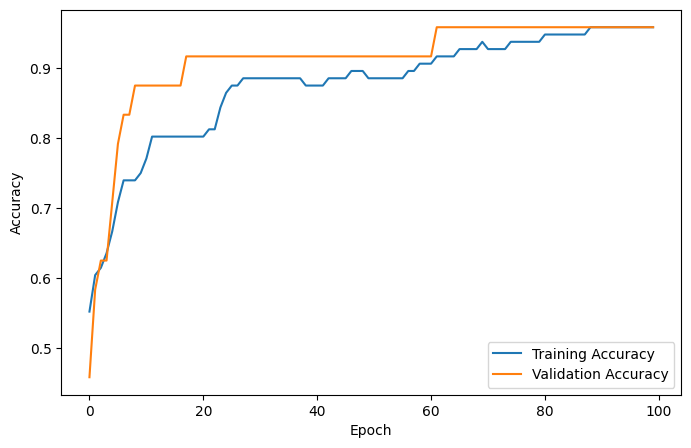

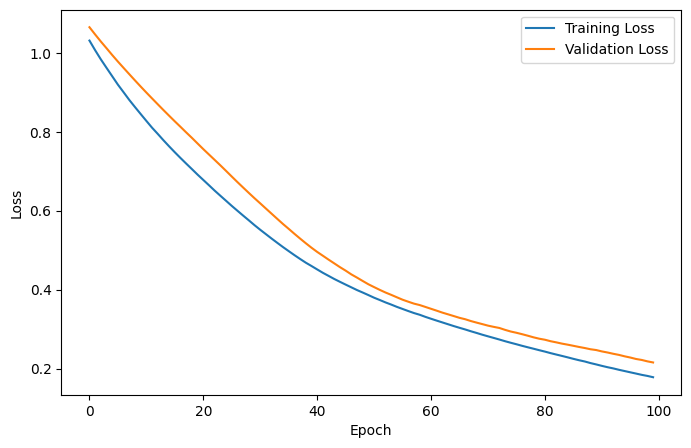

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

iris = load_iris()
x = iris.data
y= to_categorical(iris.target)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = Sequential([Dense(16, activation='relu', input_shape=(4,)),
                    Dense(16, activation='relu'),
                    Dense(3, activation='softmax')

])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train,y_train, epochs=100, validation_split=0.2, verbose=1)

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('accuary_graph.png')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_graph.png')
plt.show()

Task 6: Build a Digit Recognition Model

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9273 - loss: 0.2478 - val_accuracy: 0.9693 - val_loss: 0.1112
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9683 - loss: 0.1054 - val_accuracy: 0.9735 - val_loss: 0.0888
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9766 - loss: 0.0743 - val_accuracy: 0.9773 - val_loss: 0.0808
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9831 - loss: 0.0542 - val_accuracy: 0.9767 - val_loss: 0.0801
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0434 - val_accuracy: 0.9805 - val_loss: 0.0830
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0739
Test Accuracy: 97.74%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Sample 1
Actual digit : 7
Predicted Digit: 7
Confidence score: 99.99%


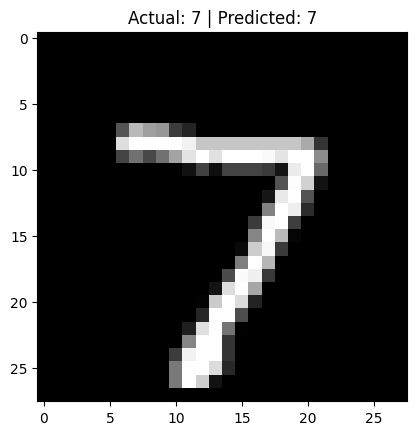

Sample 2
Actual digit : 2
Predicted Digit: 2
Confidence score: 100.00%


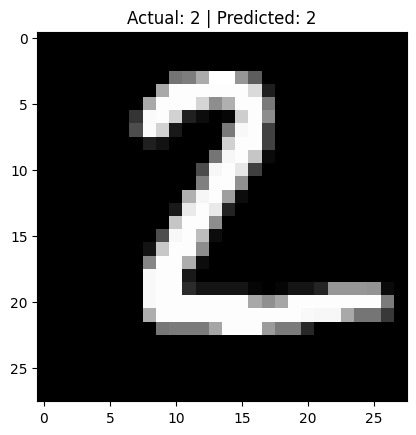

Sample 3
Actual digit : 1
Predicted Digit: 1
Confidence score: 99.98%


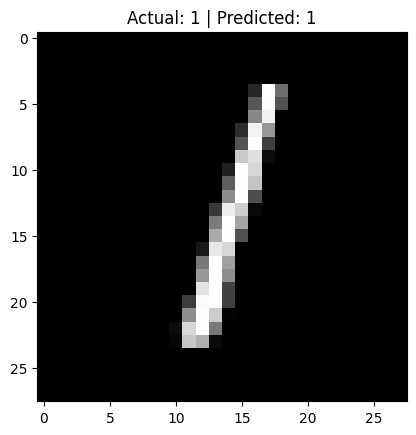

Sample 4
Actual digit : 0
Predicted Digit: 0
Confidence score: 99.95%


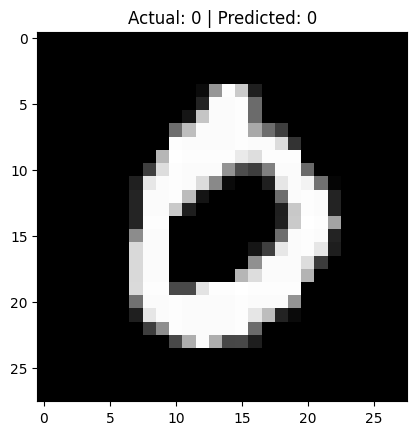

Sample 5
Actual digit : 4
Predicted Digit: 4
Confidence score: 99.93%


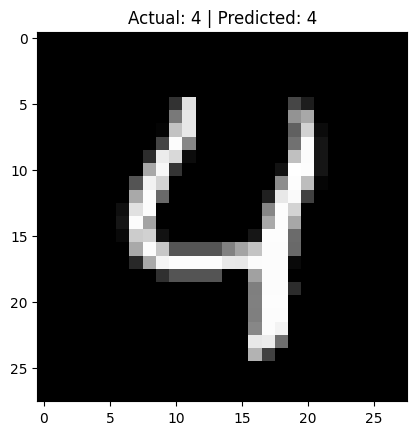

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

model = Sequential([
     Flatten(input_shape=(28,28)),
     Dense(128, activation='relu'),
     Dense(64, activation='relu'),
     Dense(10, activation='softmax')
 ])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train_cat, epochs=5, batch_size=32, validation_split=0.1)
loss, accuracy = model.evaluate(x_test, y_test_cat)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

predictions = model.predict(x_test)
for i in range(5):
 predicted_digit = np.argmax(predictions[i])
 confidence = np.max(predictions[i]) * 100

 print(f"Sample {i+1}")
 print(f"Actual digit : {y_test[i]}")
 print(f"Predicted Digit: {predicted_digit}")
 print(f"Confidence score: {confidence:.2f}%")

 plt.imshow(x_test[i], cmap='gray')
 plt.title(f"Actual: {y_test[i]} | Predicted: {predicted_digit}")
 plt.show()


Task 7: Model Saving and Loading

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential([
     Flatten(input_shape=(28,28)),
     Dense(128, activation='relu'),
     Dense(64, activation='relu'),
     Dense(10, activation='softmax')
 ])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train_cat, epochs=5, batch_size=32, validation_split=0.1)

model.save('digit_model.h5')
print('Model saved as digit_model.h5')

loaded_model = load_model('digit_model.h5')
print("Model loaded successfully")

loss, accuracy = loaded_model.evaluate(x_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

prediction = loaded_model.predict(x_test[:1])

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence Score: {confidence:.2f}%")

print("\n Prediction Result")
print("Predicted Digit:", predicted_digit)
print(f"Confidence Score: {confidence:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9256 - loss: 0.2554 - val_accuracy: 0.9695 - val_loss: 0.1042
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9674 - loss: 0.1074 - val_accuracy: 0.9713 - val_loss: 0.0977
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9772 - loss: 0.0739 - val_accuracy: 0.9692 - val_loss: 0.1078
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9823 - loss: 0.0571 - val_accuracy: 0.9765 - val_loss: 0.0825
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9855 - loss: 0.0454 - val_accuracy: 0.9782 - val_loss: 0.0800


Model saved as digit_model.h5
Model loaded successfully
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9779 - loss: 0.0821
Test Accuracy: 97.79%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Digit: 7
Confidence Score: 100.00%

 Prediction Result
Predicted Digit: 7
Confidence Score: 100.00%


Bonus Challenge - digit prediction app


In [ ]:
import streamlit as st
import numpy as np
from PIL import Image
from tensorflow.keras.model import load_model

model = load_model('digit_model.h5')
st.title("Handwritten Digit Prediction App")

uploaded_file = st.file_uploader("Upload an digit image ", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
  image = Image.open(uploaded_file).convert('L')
  st.image(image, caption='Uploaded Image', width=200)

  image = image.resize((28,28))
  image_array = np.array(image)
  image_array = 255 - image_array
  image_array = image_array / 255.0
  image_array = image_array.reshape(1, 28,28)

  prediction = model.predict(image_array)
  predicted_digit = np.argmax(prediction)
  confidence = np.max(prediction) * 100

  st.success(f"Predicted Digit: {predicted_digit}")
  st.info(f"Confidence Score: {confidence:.2f}%")

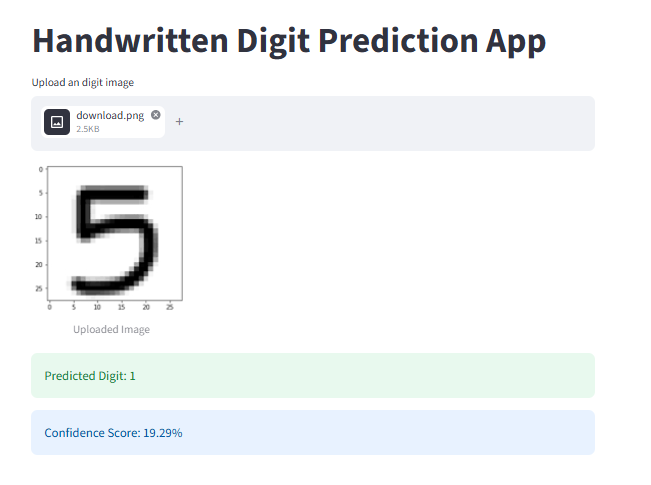)